## Matched filtering for tau

WORK IN PROGRESS: Build noise statistics
- bring tau function to external script
- find a way to get faster function. 


TO DO: CHECKS: <br>
Compute $\tau_{rs}$ multiple times and build distribution: noise should give bias oscillating around zero, not systematic bias in one direction. 
- study differnce in Cls computed from map 1) sliced directly on computation  2) computed to lmax and sliced later  --> study impact on tau results

IDEAS: 
- find method to determine optimal ell range for matched filtering 


EVENTUALLY: 
- bring 4 plots function to external script
- extend to other planck channels
- add funciton to compute FWHM of beam (and maybe also beam radius) -- could add to the read_beam function


QUESTIONS: 
- do I need to slice Cls later or directly at computation?
- how to account for uncertainties from the template when computing sigma_tau?
- Noise subtraction case:subtracted from Cl_cross --> Do I need to also modify the covariance=Cls_data to account for this? How to account for this?  
- How to perform noise subtraction at the map level?


IDEAS: 
- if we establish that different templates bias in different wasy we could use this in some way


ATTEMPTS:
- tried to re-convolve with gaussian beam but the beam function remains multiplied in the final result. --> IDEA: see if it works anyway to recover tau since the template is the same (maybe works better sicne noise is not enhanced)

## Defined quantities: 

| Variable | Description | Derivied quantities|
|----------|-------------|------------|
| `nside`   | same for all CMB and beam maps |
| `lmax`    | for maps Cls, derived from nside| `ll` array [0-lmax]|
| `lmax_PLA`| for theoretical PLA Cls |`llPLA` array [2-lmax_PLA] |
| `tau_th`  | input value for resonant scattering optical depth |  `tau_arr` [0-lmax], `tau_arrPLA` [2-lmax_PLA] |
| `lmax_beam`    | for deconvolved maps| `ll_cut` array [0-lmax_beam]|
| `sigma_pix30`| $\sigma_N [\mu K]$ noise in T-CMB units, scales to pixel  |   |






In [1]:
# %matplotlib widget
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import importlib
import os

import functions_rot as frot
import functions_beams as fbeams
import functions_tau as ftau

In [ ]:
importlib.reload(ftau)
importlib.reload(fbeams)
importlib.reload(frot)

<module 'functions_rot' from '/home/evanetti/BEAMS/beams_code/functions_rot.py'>

In [3]:
#### READ FILES ####
dir_="/home/evanetti/BEAMS/code_input/"

# original CMB maps
fcmb='convolved_maps/map0.fits'
map_cmb=hp.fitsfunc.read_map(dir_+fcmb, field=0)
fxi='convolved_maps/map_xi.fits'
map_xi=hp.fitsfunc.read_map(dir_+fxi, field=0)

# convolved CMB maps 
f0="convolved_maps/map0_convolved_map1024_fast_mpi.fits"
f1='convolved_maps/map_xi_convolved_map1024_fast_mpi.fits'
map0=hp.fitsfunc.read_map(dir_+f0, field=0) #30 GHz
map1=hp.fitsfunc.read_map(dir_+f1, field=0) #70 GHz

# beam maps
beam0, vc0 = fbeams.read_beam('30GHz', printtext=False)  # alrady normalized
beam1, vc1 = fbeams.read_beam('70GHz', printtext=False)
print('\n\n')

#Cls from PLA: 
fnamePLA='COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt' #read Cls from PLA - checked that this is lensed
lPLA, DlPLA = np.genfromtxt(dir_+fnamePLA, dtype="float", comments="#", usecols=(0,1), unpack=True)
normClPLA=lPLA*(lPLA+1)/(2*np.pi)
ClPLA=DlPLA/normClPLA

# SET Nside for maps:
nside0=hp.get_nside(map0) 
nside1=hp.get_nside(map1)
nside_beam0=hp.get_nside(beam0)
nside_beam1=hp.get_nside(beam1)

nside=min(nside0, nside1, nside_beam0, nside_beam1)
nside_arr=np.array([nside0, nside1, nside_beam0, nside_beam1])
if len(set(nside_arr)) > 1: #set(array) removes duplicates --> this checks if there is a different element 
    print('WARNING: maps have different Nside!! Downgrading to lower resolution map: nside = ', nside)
    print('Nsides=', nside_arr)
    map0=hp.pixelfunc.ud_grade(map0, nside)
    map1=hp.pixelfunc.ud_grade(map1, nside)
    beam0=hp.pixelfunc.ud_grade(beam0, nside)
    beam1=hp.pixelfunc.ud_grade(beam1, nside)
else: 
    print(f'Common Nside = {nside}')

pixArea_rad = hp.nside2pixarea(nside)



### lmax corresponding to nside: 
lmax = 3*nside-1 #for maps
print('lmax for maps: ', lmax, '\t(corresponding to Nside)')
ll=np.arange(lmax+1)

lmax_PLA=int(lPLA[-1])
print('\nlmax for PLA Cls: ', lmax_PLA)

Normalization factor =  0.9902671663946919
Normalized beam integral =  1.0
Normalization factor =  0.9910121240031213
Normalized beam integral =  0.9999999999999998



Common Nside = 1024
lmax for maps:  3071 	(corresponding to Nside)

lmax for PLA Cls:  2508


In [4]:
#### NORMalization for Cls or Dls plots 
def getnorm(option, l):
    if option=='Cls': #noise subtraction attempts 
        norm=1.
        ylabel=r'$C_\ell\,[\mu K^2]$'
    elif option=='Dls':
        norm=l*(l+1)/(2*np.pi)
        ylabel=r'$\ell(\ell+1)/2\pi\,\,C_\ell\,[\mu K^2]$'

    return norm, ylabel

In [5]:
## tau_l for theoretical maps
tau_th=1e-3
tau_arr, tau_arr2 = ftau.get_tau_arr(tau_th, lmax, plot=False)
tau_arrPLA=tau_arr[2:lmax_PLA+1]
tau_arr2PLA=tau_arr2[2:lmax_PLA+1]

lcut_tau =  30


## Beams

normalized so that $C_\ell^{beam}=1$ at large scales: <br>
beam map normalized to 1: $\sum_{pix} B_{pix} \Delta\Omega_{pix}[\rm{rad}^2]=1$   $\qquad$  should be normalized to $4\pi$ to get Cls=1<br>
further multiply: $C_l^{\rm{beam}}=4\pi \cdot$ hp.anafast(beam_map)

In [6]:
#### CHECK beam norm
print('normalized beam = ', np.sum(beam0)*pixArea_rad, np.sum(beam1)*pixArea_rad)

lmax_beam=669 # CUT higher beam multipoles
print('\nCut beam Cls at lmax_beam = ', lmax_beam)
Cls_beam0=hp.anafast(beam0, lmax=lmax_beam)*4*np.pi  # symmetrized beams, up to lmax
Cls_beam1=hp.anafast(beam1, lmax=lmax_beam)*4*np.pi 
ll_cut=ll[:lmax_beam+1]


print('Check that beam Cls are =1 on large scales')
print(f'                l={ll[0]}           l={ll[5]}               l={ll[10]}')
print('beam0: ', Cls_beam0[0], Cls_beam0[5], Cls_beam0[10] )
print('beam1: ', Cls_beam1[0], Cls_beam1[5], Cls_beam1[10] )


normalized beam =  1.0 0.9999999999999998

Cut beam Cls at lmax_beam =  669
Check that beam Cls are =1 on large scales
                l=0           l=5               l=10
beam0:  0.9999998144543507 0.9995112402878047 0.9982093769374532
beam1:  0.9999981306048545 0.9999155432763644 0.9996923222577156


In [7]:
#get beam FWHM
fwhm0=fbeams.beam_FWHM(beam0, vc0)
fwhm1=fbeams.beam_FWHM(beam1, vc1)
FWHM=max(fwhm0, fwhm1)
print('common convolution FWHM: ', FWHM)

FWHM: 0.0093 rad = 0.53 deg
FWHM: 0.0038 rad = 0.22 deg
common convolution FWHM:  0.009283646306577475


## Noise

In [8]:
nu2=np.array([   30,     44,     70,     100,    143,    217,    353,    545,    857  ]) #planck frequency channels 
sigmaN_pix, NCls_levels = ftau.convert_noise_sigma(nu2, nside, print_opt=True)  #noise sigma [μK⋅pix] in CMB T-units, amplitude of Noise Cls 
sigmaN_alms=np.sqrt(pixArea_rad)*sigmaN_pix  # or sigmaN_alms=np.sqrt(NCls_levels)

f[GHz]	σ_RJ[μK⋅deg]	σ_CMB[μK⋅deg]	σ_CMB[μK⋅pix]	 noiseCls level[μK²]
30 	2.450 		 2.508 		43.793		1.915e-03
44 	2.570 		 2.701 		47.176		2.223e-03
70 	3.080 		 3.490 		60.959		3.711e-03
100 	1.000 		 1.287 		22.473		5.044e-04
143 	0.333 		 0.551 		9.619		9.240e-05
217 	0.261 		 0.781 		13.640		1.858e-04
353 	0.198 		 2.557 		44.662		1.992e-03
545 	0.086 		 13.680 		238.910		5.700e-02
857 	0.032 		 502.570 		8777.275		7.694e+01


In [9]:
sigmaN0=sigmaN_pix[0]
sigmaN1=sigmaN_pix[2]
level_Clsnoise0=NCls_levels[0]
level_Clsnoise1=NCls_levels[2]
level_Clsnoise_diff=level_Clsnoise1+level_Clsnoise0  #expected diff map noise level

sigmaN_alms0=sigmaN_alms[0]
sigmaN_alms1=sigmaN_alms[2]

In [10]:
# deconvolved noise levels 
level_Clsnoise0_dec=level_Clsnoise0/Cls_beam0
level_Clsnoise1_dec=level_Clsnoise1/Cls_beam1
level_Clsnoise_diff_dec=level_Clsnoise0_dec+level_Clsnoise1_dec

In [11]:
#CHECK: that noise alms are generated correctly: 
almsN0=ftau.get_noise_alm(sigmaN_alms0, lmax_beam, seed=12)
almsN1=ftau.get_noise_alm(sigmaN_alms1, lmax_beam, seed=56) 

ClsN0= hp.alm2cl(almsN0)
ClsN1= hp.alm2cl(almsN1)
print('CHECK noise alms: ')
print(f'ClsN0 avg = {np.mean(ClsN0):.4e}, expected = {level_Clsnoise0_dec[0]:.4e}, diff= {np.mean(ClsN0)-level_Clsnoise0_dec[0]:.4e}')
print(f'ClsN1 avg = {np.mean(ClsN1):.4e}, expected = {level_Clsnoise1_dec[0]:.4e}, diff= {np.mean(ClsN1)-level_Clsnoise1_dec[0]:.4e}')

CHECK noise alms: 
ClsN0 avg = 1.9121e-03, expected = 1.9153e-03, diff= -3.2383e-06
ClsN1 avg = 3.7022e-03, expected = 3.7112e-03, diff= -8.9094e-06


## Matched filtering - noise statistics

In [ ]:
N=1000 #number of noise realizations

### NOISE + BEAM CASE:
lmin_tau=50
lmax_tau=250
tauBN_list, sigmatauBN_list=ftau.matched_filter_statN(map0, map1, Cls_beam0, Cls_beam1, sigmaN0, sigmaN1, map_cmb, lmin_tau, lmax_tau, N)
sigmadistBN_list=[(tauBN_list[i]-1.)/sigmatauBN_list[i] for i in range(len(tauBN_list))]

meanBN_arr=[np.mean(tauBN_list[i]) for i in range(3)]
sigmaBN_arr=[np.std(tauBN_list[i]) for i in range(3)]

In [ ]:
### NOISE ONLY CASE:
lmin_tau=50
lmax_tau=250
map0symm=hp.sphtfunc.smoothing(map_cmb, beam_window=np.sqrt(Cls_beam0), lmax=lmax_beam) #convolve with symmetrized beams
map1symm=hp.sphtfunc.smoothing(map_xi, beam_window=np.sqrt(Cls_beam1), lmax=lmax_beam)
tauN_list, sigmatauN_list=ftau.matched_filter_statN(map0symm, map1symm, Cls_beam0, Cls_beam1, sigmaN0, sigmaN1, map_cmb, lmin_tau, lmax_tau, N)
sigmadistN_list=[(tauN_list[i]-1.)/sigmatauN_list[i] for i in range(len(tauN_list))]

meanN_arr=[np.mean(tauN_list[i]) for i in range(3)]
sigmaN_arr=[np.std(tauN_list[i]) for i in range(3)]

In [ ]:
### BEAM ONLY CASE:
lmin_tau=50
lmax_tau=250
tauB_arr, sigmatauB_arr = ftau.matched_filterB(map0, map1, Cls_beam0, Cls_beam1, map_cmb, lmin_tau, lmax_tau)
sigmadistB_arr=(tauB_arr-1.)/sigmatauB_arr

In [53]:
from tabulate import tabulate

templates=['30GHz','70GHz','CMB']
result_B = [f"({v:.3f} ± {e:.3f})×10⁻³" for v, e in zip(tauB_arr, sigmatauB_arr)]
result_N = [f"({v:.3f} ± {e:.3f})×10⁻³" for v, e in zip(meanN_arr, sigmaN_arr)]
result_BN = [f"({v:.3f} ± {e:.3f})×10⁻³" for v, e in zip(meanBN_arr, sigmaBN_arr)]

print('N = ', N, 'realizations E[τ] results' )
print(tabulate({ "Template": templates, "E[τ]mean Noise only": result_N, "Noise+Beam: mean(τ)": result_BN, "Beam only: mean(τ)": result_B }, headers="keys", tablefmt="fancy_grid"))  #tablefmt="grid", "fancy_grid", "rounded_outline"

print('\n\nDeviation of mean(τ) from true value')
print(tabulate({ "Template": templates, 
                "N: mean(τ)-1": np.array(meanN_arr)-1.,  
                "N: σ/√N": np.array(sigmaN_arr)/np.sqrt(N), 
                "N+B: mean(τ)-1.": np.array(meanBN_arr)-1.,
                "N+B: σ/√N": np.array(sigmaBN_arr)/np.sqrt(N), 
                }, 
                headers="keys", tablefmt="fancy_grid", floatfmt=".4f"))  #tablefmt="grid", "fancy_grid", "rounded_outline"



N =  1000 realizations E[τ] results
╒════════════╤═══════════════════════╤═══════════════════════╤══════════════════════╕
│ Template   │ E[τ]mean Noise only   │ Noise+Beam: mean(τ)   │ Beam only: mean(τ)   │
╞════════════╪═══════════════════════╪═══════════════════════╪══════════════════════╡
│ 30GHz      │ (0.963 ± 0.319)×10⁻³  │ (1.570 ± 0.322)×10⁻³  │ (1.097 ± 0.066)×10⁻³ │
├────────────┼───────────────────────┼───────────────────────┼──────────────────────┤
│ 70GHz      │ (1.003 ± 0.320)×10⁻³  │ (0.387 ± 0.322)×10⁻³  │ (0.839 ± 0.066)×10⁻³ │
├────────────┼───────────────────────┼───────────────────────┼──────────────────────┤
│ CMB        │ (0.982 ± 0.319)×10⁻³  │ (0.216 ± 0.321)×10⁻³  │ (0.806 ± 0.066)×10⁻³ │
╘════════════╧═══════════════════════╧═══════════════════════╧══════════════════════╛


Deviation of mean(τ) from true value
╒════════════╤════════════════╤═══════════╤═══════════════════╤═════════════╕
│ Template   │   N: mean(τ)-1 │   N: σ/√N │   N+B: mean(τ)-1. │   N+B: σ/

In [ ]:
from scipy.stats import norm

def tau_hist(tau_list, sigmatau_list, sigmadist_list, n_bins):
    
    print('Nº bins = ', n_bins-1)
    print('counts = ', len(tau_list[0]))

    prob=False
    if prob==True: #probability distribution
        ylabel=r'$\mathcal{P}$'
        renorm=1.
    elif prob==False: #counts
        ylabel='counts'

    colors=['darkblue', 'darkred', 'mediumseagreen']
    colors2=['dodgerblue', 'tomato', 'lightgreen']
    labels=['30GHz', '70GHz', 'CMB']

    N=len(tau_list[0])
    

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

    plt.suptitle('Matched filter, N = ' + str(N) + ',  noise realizations', fontsize=16)

    bin_edges0 = gen_bins(n_bins, tau_list, center=1.) #nº of bins = n_nins-1      needs to be an odd number of bins --> Nbins even
    bin_width = bin_edges0[1] - bin_edges0[0] #fit gaussian curves to the data 
    if prob==False:
        renorm = N*bin_width

    for i in range(3):
        axes[0].hist(tau_list[i], bins=bin_edges0,  edgecolor=colors[i],  histtype='step', lw=2., density=prob, alpha=0.6)
        axes[0].axvline(tauB_arr[i], color=colors2[i], linestyle='--', lw=1.4) #BEAM ONLY tau VALUE 

        mean = np.mean(tau_list[i])
        sigma = np.std(tau_list[i])
        print(f'Template {i}: mean = {mean:.4f}, std = {sigma:.4f}') 
        axes[0].axvline(mean, color=colors[i], linestyle='-', lw=1.4)
        x=np.linspace(np.min(tau_list[i]), np.max(tau_list[i]), 300)
        axes[0].plot(x, norm.pdf(x, mean, sigma)*renorm, color=colors[i], lw=1.5)
        
    axes[0].axvline(1., color='dimgray', linestyle='--', lw=2.)
    #axes[0].axvspan(1.- sigma/np.sqrt(N), 1.+ sigma/np.sqrt(N), color='gray', alpha=0.3)
    axes[0].set_xlabel(r'$E[\tau] \times 10^3$', fontsize=16)


    bin_edges1 = gen_bins(n_bins, sigmatau_list) #nº of bins = n_nins-1      needs to be an odd number of bins --> Nbins even
    axes[1].hist(sigmatau_list[0], bins=bin_edges1,  edgecolor=colors[0], histtype='step', lw=2., density=prob)
    axes[1].hist(sigmatau_list[1], bins=bin_edges1,  edgecolor=colors[1], histtype='step', lw=2., density=prob)
    axes[1].hist(sigmatau_list[2], bins=bin_edges1,  edgecolor=colors[2], histtype='step', lw=2., density=prob)
    axes[1].set_xlabel(r'$\sigma_\tau \times 10^3$', fontsize=16)

    bin_edges2 = gen_bins(n_bins, sigmadist_list, center=0) #nº of bins = n_nins-1      needs to be an odd number of bins --> Nbins even
    axes[2].hist(sigmadist_list[0], bins=bin_edges2, edgecolor=colors[0], histtype='step', lw=2., label=labels[0], density=prob)
    axes[2].hist(sigmadist_list[1], bins=bin_edges2,edgecolor=colors[1], histtype='step', lw=2., label=labels[1], density=prob)
    axes[2].hist(sigmadist_list[2], bins=bin_edges2,edgecolor=colors[2], histtype='step', lw=2., label=labels[2], density=prob)
    axes[2].axvline(0., color='dimgray', linestyle='--', lw=2.)
    #for i in range(3):
    #    axes[2].axvline(sigmadistB_arr[i], color=colors2[i], linestyle='-', lw=1.4, label='Beam only '+labels[i]) #BEAM ONLY sigma-tau VALUE 
    axes[2].set_xlabel(r'$\sigma$-distance', fontsize=16)




    for ax in axes:
        ax.set_yscale('log')
        ax.set_ylabel(ylabel, fontsize=18)

    leg=plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=15, title='Template')
    leg.get_title().set_fontsize(15)
    plt.tight_layout()
    plt.savefig('histograms.png', dpi=150)
    plt.show()

    return 0

# SEPARATION LINE ____________________________________________________________________________

ATTEMPT: further noise subtraction --> on template Cls, on covariance? 

is there correlation due to the fact that both diff map and template are deconvolved with a beam? 

interpret the bias. 


MATCHED FILTER from alms: 

improve: start from beam maps [need an additional function to normalize beams]

improve: take only freq. as imput and read everything elseCls_beam0_cut


CHECKS: 
1) done: results for beam only case are the same as in map level computations 
2) to do: check noise case results with map level computations (need same noise realization!)

In [ ]:
importlib.reload(ftau)

In [ ]:
def scott_bins(data):
    N = len(data)
    sigma = np.std(data, ddof=1)  # sample std with Bessel correction
    
    bin_width = 3.49 * sigma / N**(1/3)
    n_bins = int(np.ceil((data.max() - data.min()) / bin_width))
    
    return n_bins

print(scott_bins(data))


Nº bins =  39
counts =  5000
Template 0: mean = 1.5854, std = 0.3154
Template 1: mean = 0.4028, std = 0.3154
Template 2: mean = 0.2322, std = 0.3152


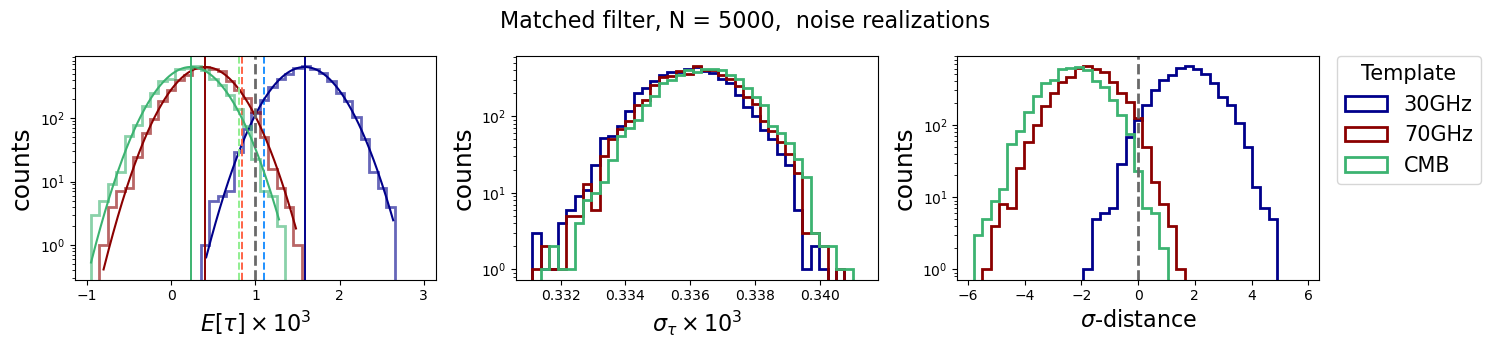

Nº bins =  39
counts =  5000
Template 0: mean = 0.9795, std = 0.3131
Template 1: mean = 1.0191, std = 0.3135
Template 2: mean = 0.9987, std = 0.3131


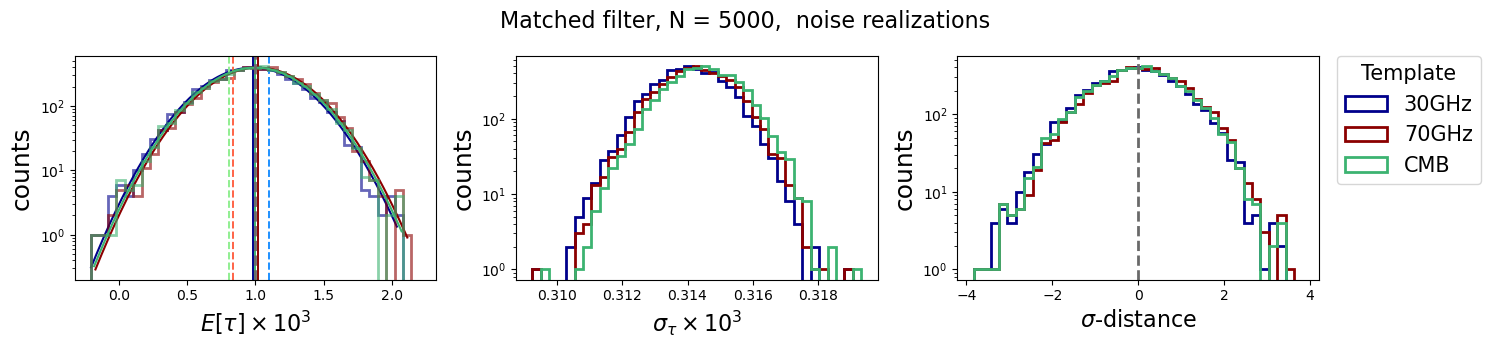

0

In [32]:
n_bins=40
tau_hist(tauBN_list, sigmatauBN_list, sigmadistBN_list, n_bins)
tau_hist(tauN_list, sigmatauN_list, sigmadistN_list, n_bins)

mean = 0.9941, std = 0.3148


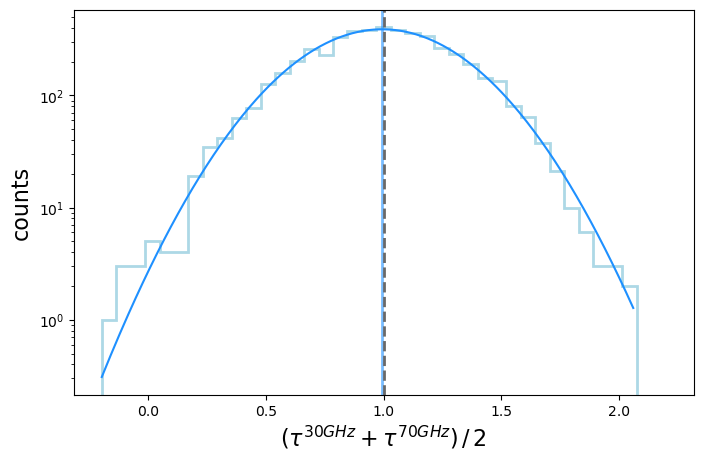

In [ ]:
### ATTEMPT: solution to bias in B+N case


#### PLOT THE DIFFERENCE

diff_tau=(tauBN_list[0]+tauBN_list[1])/2
mean = np.mean(diff_tau)
sigma = np.std(diff_tau)
print(f'mean = {mean:.4f}, std = {sigma:.4f}') 

n_bins=40
bin_edges = gen_bins(n_bins, [diff_tau, diff_tau], center=1.) #nº of bins = n_nins-1      needs to be an odd number of bins --> Nbins even
bin_width = bin_edges[1] - bin_edges[0] #fit gaussian curves to the data 
renorm = N*bin_width


plt.figure(figsize=(8, 5))
plt.hist(diff_tau, bins=bin_edges, density=False, edgecolor='lightblue',  histtype='step', lw=2., alpha=1.)
plt.axvline(mean, color='dodgerblue', linestyle='-', lw=2., alpha=0.6)
plt.axvline(1., color='dimgray', linestyle='--', lw=2.)

x=np.linspace(np.min(diff_tau), np.max(diff_tau), 300)
plt.plot(x, norm.pdf(x, mean, sigma)*renorm, color='dodgerblue', lw=1.5)

plt.yscale('log')

plt.xlabel(r"$(\tau^{30 GHz}+\tau^{70 GHz})\,/\,2$", fontsize=16)
plt.ylabel("counts", fontsize=16)

plt.show()

In [ ]:
### create noise maps:
npix=hp.nside2npix(nside) # generate noise map
map_noise0 = np.random.normal(loc=0.0, scale=sigmaN0, size=npix)
map_noise1 = np.random.normal(loc=0.0, scale=sigmaN1, size=npix)
map_noise10=map_noise1-map_noise0  

In [ ]:
### CHECK: that alm noise is generated correctly
ClsN0= hp.alm2cl(almsN0_)
Cls_mapN0=hp.anafast(map_noise0, lmax=lmax_beam)

plt.plot(ll_cut, Cls_noise30_, label='noise alms', color='dodgerblue')
plt.plot(ll_cut, Cls_map_noise30_, label='noise maps', color='red', alpha=0.5)
plt.hlines(level_Clsnoise0, ll_cut[0], ll_cut[-1], lw=2, colors='k', linestyles='dashed', label=r'$\sigma_{\rm{pix}}^2\Delta\Omega_{\rm{pix}}$')
plt.legend(fontsize=16)
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell$', fontsize=20)
plt.title(r'Noise $a_{\ell m}$', fontsize=16)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [ ]:
### CHECK RESULTS 
print('E[tau]x10³ \t sigma_tau [x10³] \t sigma-dist')
for i in range(10):
    print(f'{tau_arr[i]*1e3:.3f}\t\t  {sigmatau_arr[i]*1e3:.3f} \t\t{(tau_arr[i]-0.001)/sigmatau_arr[i]:.2f}')

In [ ]:
alm_map0=hp.map2alm(map0, lmax=lmax_beam) #do once out of function 
alm_map1=hp.map2alm(map1, lmax=lmax_beam)
#map_list=[map0, map1, map0-map1]
#alm_maps=hp.map2alm(map_list, lmax=lmax_beam)

bl0_inv=1/np.sqrt(Cls_beam0_cut) ### NOTA: CLs_beam need to be cut to lmin_tau, lmax_tau
bl1_inv=1/np.sqrt(Cls_beam1_cut)

In [ ]:
alm_map0_n=alm_map0+alms30  #add noise to maps
alm_map1_n=alm_map1+alms70

alm_map0_dec=hp.almxfl(alm_map0_n, bl0_inv)  #deconvolve 
alm_map1_dec=hp.almxfl(alm_map1_n, bl1_inv)   
alm_mapdiff=alm_map0_dec-alm_map1_dec #--> DATA for matched filter

In [ ]:
#### TEST: do matched filter with alms for noiseless case and see if result is the same

alm_data=alm_mapdiff
alm_template=alm_map0_dec

Cl_data=hp.alm2cl(alm_data)  #can add lmax, lmax_out
Cl_template=hp.alm2cl(alm_template)  #template is clean map
Cl_cross=hp.alm2cl(alm_data, alm_template)


In [ ]:
Cl_cov=Cl_data
lmin_tau=50
lmax_tau=250

t, s = tau_estimate_alms(Cl_cross, Cl_template, Cl_cov, lmin_tau, lmax_tau)
print(t*1e3,s*1e3)

In [ ]:
### CHECK: that alm noise is generated correctly
Cls_noise30_= hp.alm2cl(alms30)
Cls_map_noise30_=hp.anafast(map_noise0, lmax=lmax_beam)

plt.plot(ll_cut, Cls_noise30_, label='noise alms', color='dodgerblue')
plt.plot(ll_cut, Cls_map_noise30_, label='noise maps', color='red', alpha=0.5)
plt.hlines(level_Clsnoise0, ll_cut[0], ll_cut[-1], lw=2, colors='k', linestyles='dashed', label=r'$\sigma_{\rm{pix}}^2\Delta\Omega_{\rm{pix}}$')
plt.legend(fontsize=16)
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell$', fontsize=20)
plt.title(r'Noise $a_{\ell m}$', fontsize=16)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [ ]:
def tau_estimate_alms(Cl_cross, Cl_template, Cl_cov, lmin_tau, lmax_tau): 
    l=np.arange(lmin_tau, lmax_tau)
    nom_l=(2*l+1)*Cl_cross[lmin_tau:lmax_tau]/Cl_cov[lmin_tau:lmax_tau]
    denom_l=(2*l+1)*Cl_template[lmin_tau:lmax_tau]/Cl_cov[lmin_tau:lmax_tau]
    tauE=np.sum(nom_l)/np.sum(denom_l)
    sigma_tauE=np.sqrt(1/np.sum(denom_l) )

    return tauE, sigma_tauE

## Prepare maps 

In [25]:
### REAL BEAM + NOISE:
map0_n=map0+map_noise0 #add noise
map1_n=map1+map_noise1

map0_n_dec=hp.sphtfunc.smoothing(map0_n, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_beam)  # deconvolve noisy maps
map1_n_dec=hp.sphtfunc.smoothing(map1_n, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_beam)
map10_n=map0_n_dec-map1_n_dec


### REAL BEAM, NOISELESS
map0_dec=hp.sphtfunc.smoothing(map0, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_beam)  # deconvolve initial maps
map1_dec=hp.sphtfunc.smoothing(map1, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_beam)
map10=map0_dec-map1_dec


### SYMM BEAM + NOISE: convolve maps with symmetrized beam, in harmonic space 
map0symm=hp.sphtfunc.smoothing(map_cmb, beam_window=np.sqrt(Cls_beam0_cut), lmax=lmax_beam) #convolve with symmetrized beams
map1symm=hp.sphtfunc.smoothing(map_xi, beam_window=np.sqrt(Cls_beam1_cut), lmax=lmax_beam)

map0symm_n=map0symm+map_noise0 #add noise
map1symm_n=map1symm+map_noise1

map0symm_n_dec=hp.sphtfunc.smoothing(map0symm_n, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_beam)  # deconvolve noisy maps
map1symm_n_dec=hp.sphtfunc.smoothing(map1symm_n, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_beam)
map10symm_n=map0symm_n_dec-map1symm_n_dec 

NameError: name 'map_noise0' is not defined

In [ ]:
###############################
### Cls of deconvolved maps ###
###############################

### REAL BEAM + NOISE:
Cls_map0_n_dec=hp.anafast(map0_n_dec, lmax=lmax_beam) 
Cls_map1_n_dec=hp.anafast(map1_n_dec, lmax=lmax_beam)
Cls_map10_n=hp.anafast(map10_n, lmax=lmax_beam)

### REAL BEAM, NOISELESS
Cls_map0_dec=hp.anafast(map0_dec, lmax=lmax_beam)
Cls_map1_dec=hp.anafast(map1_dec, lmax=lmax_beam)
Cls_map10=hp.anafast(map10, lmax=lmax_beam)

### SYMM BEAM + NOISE:
Cls_map0symm_n_dec=hp.anafast(map0symm_n_dec, lmax=lmax_beam) 
Cls_map1symm_n_dec=hp.anafast(map1symm_n_dec, lmax=lmax_beam)
Cls_map10symm_n=hp.anafast(map10symm_n, lmax=lmax_beam)

In [ ]:
## plot histogram of tau values


In [ ]:
#Theory Cls: 
Cls_map_cmb=hp.anafast(map_cmb, lmax=lmax_beam)
Cls_map_xi=hp.anafast(map_xi, lmax=lmax_beam)

mapdiff_th=map_cmb-map_xi
Cls_mapdiff_th=hp.anafast(mapdiff_th, lmax=lmax_beam)

In [ ]:
## CROSS: diff map x 30 GHz map
Cls_cross_real_n = hp.anafast(map10_n, map0_n_dec, lmax=lmax_beam)
Cls_cross_real = hp.anafast(map10, map0_dec, lmax=lmax_beam)
Cls_cross_symm_n = hp.anafast(map10symm_n, map0symm_n_dec, lmax=lmax_beam)
Cls_cross_th = hp.anafast(mapdiff_th, map_cmb, lmax=lmax_beam)

## noise subtraction
Cls_cross_real_n_ = Cls_cross_real_n-level_Clsnoise0_dec
Cls_cross_symm_n_ = Cls_cross_symm_n-level_Clsnoise0_dec

# Matched filtering

In [ ]:
#1) Matched filter with covariance approx. by the data
def tau_estimate(map_data, map_template, lmin_tau, lmax_tau, Cls_cov=None, Cls_noise=None, plot=False):
    '''
    Args: 
    - map_data: difference map between 2 different frequency channels, containing signal+noise+sysrematics+foregrouds
    - map_template: opt.1) map for a clean frequency    opt.2) CMB map obtained from component separation
    - lmin_tau, lmax_tau: multipole range for tau estimation
    - (opt)Cls_cov: covariance for the matched filter. If not provided, use Cls_data (APPROX)  
    - (opt)Cls_noise: noise for Cls_cross (data x template). If not provided, no noise subtraction is applied.
    '''

    Cl_template=hp.anafast(map_template, lmax=lmax_tau)  #TEMPLATE: Cls of clean map // Cls CMB
    Cl_data=hp.anafast(map_data, lmax=lmax_tau)      #DATA: difference map between two frequencies
    Cl_cross=hp.anafast(map_data, map_template, lmax=lmax_tau)     #cross-Cls of DATA x TEMPLATE
    
    if Cls_cov is None: 
        cov=Cl_data #default: 1) approx Cl_cov=Cl_data (if covariance is not provided)   
        cov_info='Cls_cov=Cls_data'

    else: 
        cov=Cls_cov[:lmax_tau+1] #if Cls_cov is provided use that. Cases 2)use known noise statistics and 3)test with real data covariance
        cov_info='Cls_cov=Provided'

    sn=''
    if Cls_noise is not None:  #noise subtraction
        Cl_cross=Cl_cross-Cls_noise[:lmax_tau+1]
        sn=' noise subtracted'
    

    l=np.arange(lmax_tau+1)   
    
    #matched filter equation:Cls_noise
    nom_l=(2*l[lmin_tau:]+1)*Cl_cross[lmin_tau:]/cov[lmin_tau:]
    denom_l=(2*l[lmin_tau:]+1)*Cl_template[lmin_tau:]/cov[lmin_tau:]
    tauE=sum(nom_l)/sum(denom_l)
    sigma_tauE=np.sqrt(1/sum(denom_l))

    #compute sigma distance: 
    tau_th=1e-3
    sigma_dist=abs(tauE-tau_th)/sigma_tauE
    print(f'E[tau] = ({tauE*1e3:.3f}±{sigma_tauE*1e3:.3f})x10⁻³  \t sigma dist: {sigma_dist:.3f}\t err. interval: [{(tauE-sigma_tauE)*1e3:.3f}-{(tauE+sigma_tauE)*1e3:.3f}]x10⁻³ {sn}, {cov_info}')


    if plot==True:

        print(f'nom={sum(nom_l):.3e} \t denom={sum(denom_l):.3e}')

        plt.figure(figsize=(11,3.5))
        #plt.plot(l[lmin_tau:], Cl_cross[lmin_tau:]/cov[lmin_tau:], label=r'$C_\ell^{\rm{cross}}/C_\ell^{\rm{cov}}$', color='tab:red', ls='--')
        plt.plot(l[lmin_tau:], (2*l[lmin_tau:]+1)*Cl_cross[lmin_tau:]/cov[lmin_tau:], label=r'$(2\ell+1)C_\ell^{\rm{cross}}/C_\ell^{\rm{cov}}$', color='red') 
        plt.hlines(sum(nom_l), l[lmin_tau] , l[-1], color='red', ls=':', lw=2.,  alpha=0.3)  

        #plt.plot(l[lmin_tau:], Cl_template[lmin_tau:]/cov[lmin_tau:], label=r'$C_\ell^{\rm{temp}}/C_\ell^{\rm{cov}}$', color='darkblue', ls='--')  #deconvolved 30GHz map
        plt.plot(l[lmin_tau:], (2*l[lmin_tau:]+1)*Cl_template[lmin_tau:]/cov[lmin_tau:], label=r'$(2\ell+1)C_\ell^{\rm{temp}}/C_\ell^{\rm{cov}}$', color='blue', ls='-')
        plt.hlines(sum(denom_l), l[lmin_tau] , l[-1], color='blue', ls=':', lw=2., alpha=0.3)  


        plt.hlines(0., l[lmin_tau] , l[-1], color='black', ls='--', lw=1) 

        plt.xscale('linear')
        plt.yscale('symlog', linthresh=1e-5)
        plt.xlabel(r'$\ell$', fontsize=18)
        plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
        plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=13)
        plt.tight_layout()
        plt.show()

    return tauE, sigma_tauE

In [ ]:
lmin_tau=50
lmax_tau=250

# REALISTIC BEAM, NOISELESS
print('\nRealistic beam (noiseless)')
tauB_cmb, sigma_tauB_cmb=tau_estimate(map10, map_cmb, lmin_tau, lmax_tau)
tauB_30, sigma_tauB_30=tau_estimate(map10, map0_dec, lmin_tau, lmax_tau)
tauB_70, sigma_tauB_70=tau_estimate(map10, map1_dec, lmin_tau, lmax_tau)

# SYMMETRIC NOISE
print('\nSymmetric noise only')
tauN_cmb, sigma_tauN_cmb=tau_estimate(map10symm_n, map_cmb, lmin_tau,  lmax_tau)
tauN_30, sigma_tauN_30=tau_estimate(map10symm_n, map0symm_n_dec, lmin_tau,  lmax_tau)
tauN_30subtr, sigma_tauN_30subtr=tau_estimate(map10symm_n, map0symm_n_dec, lmin_tau,  lmax_tau, Cls_noise=level_Clsnoise0_dec)
tauN_70, sigma_tauN_70=tau_estimate(map10symm_n, map1symm_n_dec, lmin_tau,  lmax_tau)
tauN_70subtr, sigma_tauN_70subtr=tau_estimate(map10symm_n, map1symm_n_dec, lmin_tau,  lmax_tau, Cls_noise=-level_Clsnoise1_dec)

# REALISTIC BEAM + NOISE
print('Realistic beam + noise')
tauBN_cmb, sigma_tauBN_cmb=tau_estimate(map10_n, map_cmb, lmin_tau, lmax_tau)  
tauBN_30, sigma_tauBN_30=tau_estimate(map10_n, map0_n_dec, lmin_tau, lmax_tau)  
tauBN_30subtr, sigma_tauBN_30subtr=tau_estimate(map10_n, map0_n_dec, lmin_tau, lmax_tau, Cls_noise=level_Clsnoise0_dec)  
tauBN_70, sigma_tauBN_70=tau_estimate(map10_n, map1_n_dec, lmin_tau, lmax_tau)  
tauBN_70subtr, sigma_tauBN_70subtr=tau_estimate(map10_n, map1_n_dec, lmin_tau, lmax_tau, Cls_noise=-level_Clsnoise1_dec)  


In [ ]:
from tabulate import tabulate
import pandas as pd

In [ ]:
### visualize results 
cases = ["CMB", "30GHz", "70GHz", "30GHz-N", "70GHz-N"]

tauB=np.array([tauB_cmb, tauB_30, tauB_70, np.nan, np.nan])
tauN=np.array([tauN_cmb, tauN_30, tauN_70, tauN_30subtr, tauN_70subtr])
tauBN=np.array([tauBN_cmb, tauBN_30, tauBN_70, tauBN_30subtr, tauBN_70subtr])

sigma_tauB=np.array([sigma_tauB_cmb, sigma_tauB_30, sigma_tauB_70, np.nan, np.nan])
sigma_tauN=np.array([sigma_tauN_cmb, sigma_tauN_30, sigma_tauN_70, sigma_tauN_30subtr, sigma_tauN_70subtr])
sigma_tauBN=np.array([sigma_tauBN_cmb, sigma_tauBN_30, sigma_tauBN_70, sigma_tauBN_30subtr, sigma_tauBN_70subtr])

result_B_ = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauB, sigma_tauB)]
result_N_ = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauN, sigma_tauN)]
result_BN_ = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauBN, sigma_tauBN)]

tau_true=0.001
biasB=tauB-tau_true
biasN=tauN-tau_true
biasBN=tauBN-tau_true

sigmadistB=np.abs(biasB)/sigma_tauB
sigmadistN=np.abs(biasN)/sigma_tauN
sigmadistBN=np.abs(biasBN)/sigma_tauBN

idxB = np.nanargmin(sigmadistB)
idxN = np.nanargmin(sigmadistN)
idxBN = np.nanargmin(sigmadistBN)

arrays = [
    ["Template", "beam only",    "beam only",    "beam only",    "noise only",   "noise only",   "noise only",   "beam+noise", "beam+noise", "beam+noise"],
    ["",         "E[tau][×10⁻³]",  "b[×10⁻³]",    "σ_dist",  "E[tau][×10⁻³]",  "b[×10⁻³]",    "σ_dist",  "E[tau][×10⁻³]",     "b[×10⁻³]",       "σ_dist"] 
    ]
multi_col = pd.MultiIndex.from_arrays(arrays)
data = list(zip(cases, result_B_, biasB*1e3, sigmadistB, result_N_, biasN*1e3, sigmadistN, result_BN_, biasBN*1e3, sigmadistBN))   
df = pd.DataFrame(data, columns=multi_col)

# format bias and sigma_dist columns
for group in ["beam only", "noise only", "beam+noise"]:
    df[group, "b[×10⁻³]"]   = df[group, "b[×10⁻³]"].map(lambda x: f"{x:.2f}")
    df[group, "σ_dist"] = df[group, "σ_dist"].map(lambda x: f"{x:.2f}")

print(df.to_string(col_space=[10, 20, 8, 6, 20, 8, 6, 20, 8, 6]))

### PLOT results
colors = ["tab:red", "dodgerblue", "darkblue"]  #beam only, noise only, realistic

y = np.arange(len(cases))
y=y/10

fig, ax = plt.subplots(figsize=(8,4))
for i in range(len(cases)):
    ax.errorbar( tauB[i], y[i], xerr=sigma_tauB[i], color=colors[0], ecolor=colors[0], markersize=8, elinewidth=3, capsize=6, alpha=0.6, zorder=2 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    if i==idxB:
        ax.scatter( tauB[idxB], y[idxB], facecolors='orange', edgecolors=colors[0], s=120, marker='*', zorder=5, label='noise only' if i==0 else '_nolegend_') 
    else:
        ax.scatter( tauB[i], y[i], color=colors[0], s=50, zorder=2, label='beam only'  if i==0 else '_nolegend_')


    ax.errorbar( tauN[i], y[i], xerr=sigma_tauN[i], color=colors[1], ecolor=colors[1], elinewidth=3, capsize=6, alpha=0.6, zorder=1 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    if i==idxN:
        ax.scatter( tauN[idxN], y[idxN], facecolors='orange', edgecolors=colors[1], s=150, marker='*', zorder=4, label='noise only' if i==0 else '_nolegend_')
    else:
        ax.scatter( tauN[i], y[i], color=colors[1], s=50,  zorder=1, label='noise only' if i==0 else '_nolegend_')

    ax.errorbar( tauBN[i], y[i], xerr=sigma_tauBN[i], color=colors[2], ecolor=colors[2],  elinewidth=3, capsize=6, alpha=0.6, zorder=0 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    if i==idxBN:
        ax.scatter( tauBN[idxBN], y[idxBN], facecolors='orange', edgecolors=colors[2], s=150, marker='*', zorder=3, label='realistic' if i==0 else '_nolegend_')
    else:
        ax.scatter( tauBN[i], y[i], color=colors[2], s=50,  zorder=0, label='realistic' if i==0 else '_nolegend_' )

ax.set_xticks([- 0.004, -0.003, -0.002, -0.001, 0., 0.001, 0.002, 0.003, 0.004])
ax.tick_params(axis='x', labelsize=15)
ax.set_yticks(y)
ax.set_yticklabels(cases, fontsize=15)
ax.set_xlabel(r"$\tau_{X_i}$", fontsize=20)
ax.set_ylabel(r"template", fontsize=20)

ax.set_xlim(- 0.0035, 0.0045) 
ax.set_ylim(y[0]-0.07, y[-1]+0.07)
ax.axvline(1e-3, color='black', linestyle='--', linewidth=2, alpha=0.3)  # Vertical reference line
ax.invert_yaxis()
fig.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=15)

plt.savefig("/home/evanetti/BEAMS/paper_figures/matched_filtering.pdf", format="pdf", bbox_inches="tight")

plt.show()


## Noise statistics 

loop over: 
- generate noise realization: needs only sigma_pix // convert_sigma(nu_in, nside, print_opt=False) --> sigma_pix, Ncls_level
- add to map (symm and realistic beam cases: 2)  -- need map0, map1, map0symm, map1symm 
- deconvolve: need beam windows: bl0, bl1 up to lmax_beam
- compute tau with 5 different templates: (map_data, map_template, lmin_tau, lmax_tau, Cls_noise=None). --> possible problem: get Cls_data, Cls_cross every time [most of this need to run every time]

write function to it once and see how much it takes. CHECK: to get same tau as with normal method
see if reasonable for N=100 realizations of the noise



In [ ]:
def tau_test(map0, map1, sigmaN0, sigmaN1, lmin_tau, lmax_tau):

    nside=hp.get_nside(map0)
    npix=hp.nside2npix(nside)

    N=10

    tauE_arr=np.zeros(N)
    sigma_tauE_arr=np.zeros(N)
    for i in range(N):
        #add noise to maps
        mapN0 = np.random.normal(loc=0.0, scale=sigmaN0, size=npix) ## generate at alm level
        mapN1 = np.random.normal(loc=0.0, scale=sigmaN1, size=npix)
        map0_n=map0+mapN0  #take alm of the map in input (to be computed once per convolved map)
        map1_n=map1+mapN1

        #deconvolve noise maps and compute diff map ---> perform deconvolution in harmonic space
        map0_n_dec=hp.sphtfunc.smoothing(map0_n, beam_window=bl0_inv, lmax=lmax_tau)  # deconvolve noisy maps
        map1_n_dec=hp.sphtfunc.smoothing(map1_n, beam_window=bl1_inv, lmax=lmax_tau)
        mapdiff_n=map0_n_dec-map1_n_dec #map_DATA

        #estimate tau ---> take template alms in input (maybe selecting from dictionary with the options)
        map_template=np.copy(map1_n_dec)
        Cl_template=hp.anafast(map_template, lmax=lmax_tau)  #TEMPLATE: Cls of clean map // Cls CMB
        Cl_data=hp.anafast(mapdiff_n, lmax=lmax_tau)      #DATA: difference map between two frequencies
        Cl_cross=hp.anafast(mapdiff_n, map_template, lmax=lmax_tau)     #cross-Cls of DATA x TEMPLATE ---> 5 seconds up to here
        Cl_cov=Cl_data #approximate covariance with data Cls

        #match filter
        l=np.arange(lmin_tau, lmax_tau+1)   
        nom=sum((2*l+1)*Cl_cross[lmin_tau:]/Cl_cov[lmin_tau:])
        denom=sum((2*l+1)*Cl_template[lmin_tau:]/Cl_cov[lmin_tau:])
        tauE=nom/denom
        sigma_tauE=np.sqrt(1/denom)
        tauE_arr[i]=tauE
        sigma_tauE_arr[i]=sigma_tauE


    return tauE_arr, sigma_tauE_arr


### CHECK: reproduce other plots with alms

#opt: 1) pre-compute Cls template 2) see if Cls_data can be computed earlier

# problem: when cutting at different ells the sum over ms changes too --> computing cut Cls is different from computing Cls and then cutting 
## CHECK this further with plots



In [ ]:
lmin_tau=50
lmax_tau=250

bl0_inv=1/np.sqrt(Cls_beam0_cut[:lmax_tau+1]) ### NOTA: CLs_beam need to be cut to lmin_tau, lmax_tau
bl1_inv=1/np.sqrt(Cls_beam1_cut[:lmax_tau+1])

tau,sigma_tau=tau_test(map0, map1, sigmaN0, sigmaN1, lmin_tau, lmax_tau)

In [ ]:
print('tau[x10⁻³ ]\t sigma-dist')
for i in range(len(tau)):
    print(f'{(tau[i]*1e3):.3f} ± {(sigma_tau[i]*1e3):.3f}\t {((tau[i]-0.001)/sigma_tau[i]):.3f} ' )

In [ ]:
def tau_noise_stat(map0, map1, sigmaN0, sigmaN1, lmin_tau, lmax_tau):
    '''
    Estimate the distribution of tau estimates under the null hypothesis (tau=0) by applying the matched filter to noise-only maps. 
    This can be used to compute p-values for the tau estimates obtained from real data, by comparing the observed tau to the distribution of tau under the null hypothesis.
    '''

    nside=hp.get_nside(map0)
    print('nside=', nside)
    npix=hp.nside2npix(nside)

    N=1

    for i in range(N):
        #add noise to maps
        mapN0 = np.random.normal(loc=0.0, scale=sigmaN0, size=npix)
        mapN1 = np.random.normal(loc=0.0, scale=sigmaN1, size=npix)
        map0_n=map0+mapN0
        map1_n=map1+mapN1

        #deconvolve noise maps and compute diff map
        map0_n_dec=hp.sphtfunc.smoothing(map0_n, beam_window=bl0_inv, lmax=lmax_tau)  # deconvolve noisy maps
        map1_n_dec=hp.sphtfunc.smoothing(map1_n, beam_window=bl1_inv, lmax=lmax_tau)
        mapdiff_n=map0_n_dec-map1_n_dec #map_DATA

        #estimate tau
        map_template=np.copy(map0_n_dec)
        Cl_template=hp.anafast(map_template, lmax=lmax_tau)  #TEMPLATE: Cls of clean map // Cls CMB
        Cl_data=hp.anafast(mapdiff_n, lmax=lmax_tau)      #DATA: difference map between two frequencies
        Cl_cross=hp.anafast(mapdiff_n, map_template, lmax=lmax_tau)     #cross-Cls of DATA x TEMPLATE ---> 5 seconds up to here
        Cl_cov=Cl_data #approximate covariance with data Cls

        #match filter
        l=np.arange(lmin_tau, lmax_tau+1)   
        nom=sum((2*l+1)*Cl_cross[lmin_tau:]/Cl_cov[lmin_tau:])
        denom=sum((2*l+1)*Cl_template[lmin_tau:]/Cl_cov[lmin_tau:])
        tauE=nom/denom
        sigma_tauE=np.sqrt(1/denom)

    return tauE, sigma_tauE

#opt: 1) pre-compute Cls template 2) see if Cls_data can be computed earlier

# problem: when cutting at different ells the sum over ms changes too --> computing cut Cls is different from computing Cls and then cutting 
## CHECK this further with plots


lmin_tau=50
lmax_tau=250

bl0_inv=1/np.sqrt(Cls_beam0_cut[:lmax_tau+1]) ### NOTA: CLs_beam need to be cut to lmin_tau, lmax_tau
bl1_inv=1/np.sqrt(Cls_beam1_cut[:lmax_tau+1])


t,s=tau_noise_stat(map0, map1, sigmaN0, sigmaN1, lmin_tau, lmax_tau)

In [ ]:
print(t*1e3,s*1e3)


## Convolution with gaussian beam

tau signal remains multiplies by the new gaussian beam function

In [ ]:
### REAL BEAM + NOISE:
map0_n_=hp.sphtfunc.smoothing(map0_n_dec, fwhm=FWHM, lmax=lmax_beam)  # CONVOLVE WITH THE SAME BEAM
map1_n_=hp.sphtfunc.smoothing(map1_n_dec, fwhm=FWHM, lmax=lmax_beam)
map10_n_=map0_n_-map1_n_

### REAL BEAM, NOISELESS
map0_=hp.sphtfunc.smoothing(map0_dec, fwhm=FWHM, lmax=lmax_beam)  # deconvolve initial maps
map1_=hp.sphtfunc.smoothing(map1_dec, fwhm=FWHM, lmax=lmax_beam)
map10_=map0_-map1_

### SYMM BEAM + NOISE: convolve maps with symmetrized beam, in harmonic space 
map0symm_n_=hp.sphtfunc.smoothing(map0symm_n_dec, fwhm=FWHM, lmax=lmax_beam)  # CONVOLVE WITH THE SAME BEAM
map1symm_n_=hp.sphtfunc.smoothing(map1symm_n_dec, fwhm=FWHM, lmax=lmax_beam)
map10symm_n_=map0symm_n_ - map1symm_n_

In [ ]:
### REAL BEAM + NOISE:
Cls_map0_n_=hp.anafast(map0_n_, lmax=lmax_beam) 
Cls_map1_n_=hp.anafast(map1_n_, lmax=lmax_beam)
Cls_map10_n_=hp.anafast(map10_n_, lmax=lmax_beam)

### REAL BEAM, NOISELESS
Cls_map0_=hp.anafast(map0_, lmax=lmax_beam)
Cls_map1_=hp.anafast(map1_, lmax=lmax_beam)
Cls_map10_=hp.anafast(map10_, lmax=lmax_beam)

### SYMM BEAM + NOISE:
Cls_map0symm_n_=hp.anafast(map0symm_n_, lmax=lmax_beam) 
Cls_map1symm_n_=hp.anafast(map1symm_n_, lmax=lmax_beam)
Cls_map10symm_n_=hp.anafast(map10symm_n_, lmax=lmax_beam)

In [ ]:
### IDEAL: 
map0symm_=hp.sphtfunc.smoothing(map_cmb, fwhm=FWHM, lmax=lmax_beam)  # CONVOLVE WITH THE SAME BEAM
map1symm_=hp.sphtfunc.smoothing(map_xi, fwhm=FWHM, lmax=lmax_beam)
map10symm_=map0symm_ - map1symm_

Cls_map0symm_=hp.anafast(map0symm_, lmax=lmax_beam) 
Cls_map1symm_=hp.anafast(map1symm_, lmax=lmax_beam)
Cls_map10symm_=hp.anafast(map10symm_, lmax=lmax_beam)

In [ ]:
### PLOT difference map
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
ax = ax.flatten()

#deconvolved maps
ax[0].plot(ll_cut[2:], Cls_map0_n_[2:], color='blue', ls='-', alpha=0.5, label='30 GHz') 
ax[0].plot(ll_cut[2:], Cls_map1_n_[2:], color='tab:green', ls='-', alpha=0.5, label='70 GHz')
ax[1].plot(ll_cut[2:], Cls_map0_[2:], color='blue', ls='-', alpha=0.5, label='30 GHz') 
ax[1].plot(ll_cut[2:], Cls_map1_[2:], color='tab:green', ls='-', alpha=0.5, label='70 GHz')
ax[2].plot(ll_cut[2:], Cls_map0symm_n_[2:], color='blue', ls='-', alpha=0.5, label='30 GHz') 
ax[2].plot(ll_cut[2:], Cls_map1symm_n_[2:], color='tab:green', ls='-', alpha=0.5, label='70 GHz')
ax[3].plot(ll_cut[2:], Cls_map0symm_[2:], color='blue', ls='-', alpha=0.5, label='30 GHz') #theory
ax[3].plot(ll_cut[2:], Cls_map1symm_[2:], color='tab:green', ls='-', alpha=0.5, label='70 GHz')


#difference maps
ax[0].plot(ll_cut[2:], Cls_map10_n_[2:], color='red', ls='-',  label='diff map') 
ax[1].plot(ll_cut[2:], Cls_map10_[2:], color='red', ls='-',  label='diff map') 
ax[2].plot(ll_cut[2:], Cls_map10symm_n_[2:], color='red', ls='-',  label='diff map') 
ax[3].plot(ll_cut[2:], Cls_map10symm_[2:], color='red', ls='-',  label='diff map') 


#noise
for i in [0, 2]: 
    ax[i].plot(ll_cut[2:], level_Clsnoise_diff_dec[2:], color='darkred', ls='--', lw=1,   label='diff noise') 

'''
#noise subtraction attempts 
ax[0].plot(ll_cut,Cls_map10_n_ , color='lightcoral', alpha=0.3, ls='-', lw=1.5, label='diff map (noise subtraction)', zorder=0)
ax[2].plot(ll_cut, Cls_map10symm_n_, color='lightcoral', alpha=0.3, ls='-', lw=1.5, label='diff map (noise subtraction)', zorder=0)
ax[0].plot(ll_cut[2:], Cls_map10[2:], color='red', alpha=0.3, ls='-',  label='diff map') 

#plot titles
ax[0].set_title('relistic beam + noise', fontsize=18)
ax[1].set_title('relistic beam (noiseless)', fontsize=18)
ax[2].set_title('noise only', fontsize=18)
ax[3].set_title('theory', fontsize=18)
'''

for i in range(4):
    ax[i].plot(lPLA, ClPLA, color='black', ls='--', label='CMB th. (PLA)', zorder=0)  #PLA CMB Cls 
    ax[i].plot(lPLA, tau_arr[2:lmax_PLA+1]**2*ClPLA, color='red', alpha=0.4, ls='-',  label=r'r.s. signal th: $\tau_{rs}^2 C_\ell^{\rm{CMB}}$', zorder=1) #theoretical map difference
    ax[i].set_xscale('log')
    ax[i].set_ylim(5e-11, 3e3)
    ax[i].set_yscale('log')
    #ax[i].set_yscale('symlog', linthresh=1e-8)
    ax[i].set_xlabel(r'$\ell$', fontsize=18)
    ax[i].set_ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
    ax[i].legend(fontsize=10)

fig.suptitle(r'Difference maps: $\;\;\tau_{\rm{rs}}^2 \,C_\ell^{\rm{CMB}}$, $\ell_{max}=$'+str(lmax_beam), fontsize=18, fontweight='bold')
fig.tight_layout()
plt.show() 

## All noise channels

Read all Planck beams 

convolve with symmetrized version 

add noise to the maps 

deconvolve 

In [ ]:
### generate noise maps: 
sigma_CMB_pix, NCls_levels = convert_sigma(nu2, nside, print_opt=True)  

npix=hp.nside2npix(nside) # generate noise map
map_noise0 = np.random.normal(loc=0.0, scale=sigma_CMB_pix[0], size=npix) #noise of 30 GHz map

map_noise_list=[]
map_noise_diff_list=[]
for i in range(1, len(nu2)):
    map_noise_i = np.random.normal(loc=0.0, scale=sigma_CMB_pix[i], size=npix) #noise of other maps 
    map_noise_list.append(map_noise_i)

    map_noise_diff_i=map_noise_i-map_noise0
    map_noise_diff_list.append(map_noise_diff_i)
    

# Matched filtering

$E[\tau] = \frac{(\textbf{T}_{\rm{diff}})^T C^{-1}\textbf{T}_{\rm{CMB}}}{(\textbf{T}_{\rm{CMB}})^T C^{-1}\textbf{T}_{\rm{CMB}}} 
= \frac{\sum_{\hat{n}, \hat{n}'} T^T_{\rm{diff}}(\hat{n}) C^{-1}_{\hat{n}, \hat{n}'}T_{\rm{CMB}}(\hat{n}') }{\sum_{\hat{n}, \hat{n}'}T_{\rm{CMB}}^T(\hat{n})C^{-1}_{\hat{n}, \hat{n}'}T_{\rm{CMB}}(\hat{n}')}$   
where: 
- $\textbf{T}_{\rm{diff}}=\textbf{T}_s+\textbf{T}_N$ is the data: r.s. sigmal + noise
- $\textbf{T}_{\rm{CMB}}$ is the template
- $C$ is the covariance matrix $C=\langle (\textbf{T}_{\rm{diff}}-\textbf{T}_s)(\textbf{T}_{\rm{diff}}-\textbf{T}_s)^T \rangle = \langle \textbf{T}_N \textbf{T}_N^T \rangle$, 

In Fourier space
$E[\tau]=\frac{\sum_\ell (2\ell+1) C_\ell^{\rm{diff}\times\rm{CMB}} C_\ell^{-1}}{\sum_\ell  (2\ell+1)  C_\ell^{\rm{CMB}} C_\ell^{-1}}$

where: 
- $C_\ell^{\rm{diff}\times\rm{CMB}}$ is the cross-spectrum between the difference map (data) and the template (CMB)
- $C_\ell$ is the associated to the covariance matrix. Should be the Cls of the map(data-signal), but in the real case the signal is unknown  
- NOTE: this assumes that the covariance is diagonal

Harmonic space covariance matrix: 
1. APPROX: $C_\ell\simeq C_\ell^{\rm{data}}=C_\ell^{\rm{diff}}\quad$ valid if signal $\ll$ nosie $\; \longrightarrow \; \textbf{n}=\textbf{d}-\textbf{s}\simeq \textbf{d}$  -- need to check if this is valid in this case. Check approx: compare $E[\tau_{rs}]$ extracted using covariance $C_\ell^{\rm{data}}$ or  $C_\ell^{\rm{data}-\rm{signal}}$
2. $C_\ell=C_\ell^{N}$ estimate the noise from its known statistics (account for cross-correlations between different noise components)
3. just to compare:  $C_\ell=C_\ell^{\rm{data}}-C_\ell^{\rm{signal}}=C_\ell^{\rm{diff}}-\tau_{\rm{rs}}^2 C_\ell^{\rm{CMB}}$ not possible in the real case since $\tau_{\rm{rs}}$ is unkown. Try just to see how this unkown affects the final result.

QUESTIONS: 
- how to account for uncertainties in the template? 
- in noise subtraction during match filter: noise is subtracted from Cl_cross (can't from data??) --> how do I accound for noise subtraction in the covariance?

IDEAS: 
- if we establish that different templates bias in different wasy we could use this to find systematics 

In [ ]:
def matched_filter_stat(map0, map1, Cls_beam0, Cls_beam1, sigmaN0, sigmaN1, lmin_tau, lmax_tau, N):  ## CASE: template = map0

    l=np.arange(lmin_tau, lmax_tau+1)

    alm0=hp.map2alm(map0, lmax=lmax_tau) #alms of maps to get difference map
    alm1=hp.map2alm(map1, lmax=lmax_tau)
    alm_template_cmb=hp.map2alm(map_cmb, lmax=lmax_tau)  #template from original CMB map (not convolved, no noise)

    bl0_inv=1/np.sqrt(Cls_beam0[:lmax_tau+1]) ### NOTA: CLs_beam need to be cut to lmin_tau, lmax_tau
    bl1_inv=1/np.sqrt(Cls_beam1[:lmax_tau+1])

    lmax_alm = hp.Alm.getlmax(len(alm0))  ### check if alms and bl have the same lmax
    lmax_bl  = len(bl0_inv) - 1  # bl is indexed 0..lmax
    assert lmax_alm == lmax_bl, f"ERROR: lmax mismatch: alms have lmax={lmax_alm}, bl has lmax={lmax_bl}"


    #noise for cross Cls for different templates (deconvolved noise)
    Cl_noise0=pixArea_rad*sigmaN0**2/Cls_beam0[:lmax_tau+1]
    Cl_noise1=-pixArea_rad*sigmaN1**2/Cls_beam1[:lmax_tau+1]

    MS0 = np.random.SeedSequence(88)   # master seed
    s0 = MS0.spawn(N)  

    MS1 = np.random.SeedSequence(42)   # master seed
    s1 = MS1.spawn(N)  

    tauE0=np.empty(N, dtype=float)
    tauE1=np.empty(N, dtype=float)
    tauE2=np.empty(N, dtype=float)
    sigma_tauE0=np.empty(N, dtype=float)
    sigma_tauE1=np.empty(N, dtype=float)
    sigma_tauE2=np.empty(N, dtype=float)

    sigmaN0_alms=np.sqrt(pixArea_rad)*sigmaN0
    sigmaN1_alms=np.sqrt(pixArea_rad)*sigmaN1

    for i in range(N):
        almN0=ftau.get_noise_alm(sigmaN0_alms, lmax_tau, seed=s0[i]) #generate noise
        almN1=ftau.get_noise_alm(sigmaN1_alms, lmax_tau, seed=s1[i])

        alm0_n=alm0+almN0  #add noise to maps
        alm1_n=alm1+almN1

        alm0_n_dec=hp.almxfl(alm0_n, bl0_inv)  #deconvolve 
        alm1_n_dec=hp.almxfl(alm1_n, bl1_inv)   
        alm_data=alm0_n_dec-alm1_n_dec #get data map

        Cl_cov=hp.alm2cl(alm_data, lmax=lmax_tau)  #Cls of covariance = Cls of data (APPROX.)
        Cl_cov_cut=Cl_cov[lmin_tau:] 



        ### DIFFERENT TEMPLATES: 
        alm_template0=alm0_n_dec  #templates
        alm_template1=alm1_n_dec
        alm_template2=alm_template_cmb
        Cl_crossT0=hp.alm2cl(alm_data, alm_template0, lmax=lmax_tau)-Cl_noise0     #noise subtraction
        Cl_crossT1=hp.alm2cl(alm_data, alm_template1, lmax=lmax_tau)-Cl_noise1    #noise subtraction
        Cl_crossT2=hp.alm2cl(alm_data, alm_template2, lmax=lmax_tau)    #NO noise subtraction!! since noise of diff map is not supposed to correlate

        Cl_T0=hp.alm2cl(alm_template0, lmax=lmax_tau)  #template Cls
        Cl_T1=hp.alm2cl(alm_template1, lmax=lmax_tau)  
        Cl_T2=hp.alm2cl(alm_template2, lmax=lmax_tau)  

        #MATCHED FILTER
        nom0=np.sum((2*l+1)*Cl_crossT0[lmin_tau:]/Cl_cov_cut)  #with template 1 (map nu0)
        denom0=np.sum((2*l+1)*Cl_T0[lmin_tau:]/Cl_cov_cut)
        tauE0[i]=nom0/denom0
        sigma_tauE0[i]=np.sqrt(1/denom0)


        nom1=np.sum((2*l+1)*Cl_crossT1[lmin_tau:]/Cl_cov_cut)  #with template 2 (map nu1)
        denom1=np.sum((2*l+1)*Cl_T1[lmin_tau:]/Cl_cov_cut)
        tauE1[i]=nom1/denom1
        sigma_tauE1[i]=np.sqrt(1/denom1)

        nom2=np.sum((2*l+1)*Cl_crossT2[lmin_tau:]/Cl_cov_cut)  #with template 3 (CMB)
        denom2=np.sum((2*l+1)*Cl_T2[lmin_tau:]/Cl_cov_cut)
        tauE2[i]=nom2/denom2
        sigma_tauE2[i]=np.sqrt(1/denom2)

    tauE_list=[tauE0*1e3, tauE1*1e3, tauE2*1e3]
    sigma_tauE_list=[sigma_tauE0*1e3, sigma_tauE1*1e3, sigma_tauE2*1e3]

    return tauE_list, sigma_tauE_list
